# Netflix Data Cleaning & Analysis Project
**Goal:** Analyze Netflix's Movies & TV Shows dataset to generate business insights while demonstrating data cleaning, feature engineering, EDA, and visualization.

**Tech stack:** Python, NumPy, Pandas, Matplotlib, Seaborn

> Note: This notebook uses a realistically-structured synthetic dataset (`data/netflix_titles.csv`) modeled on the public Kaggle "Netflix Titles" dataset schema, including intentional missing values, duplicates, and inconsistent formatting to practice real-world cleaning. Swap in the actual Kaggle CSV (same column names) to run this on real data.


## Phase 1 — Project Setup
Import libraries and load the dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
IMG_DIR = "../images"
os.makedirs(IMG_DIR, exist_ok=True)

df = pd.read_csv("../data/netflix_titles.csv")
print("Shape:", df.shape)
df.head()


Shape: (1225, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s52,Movie,Last Shadow,Noah Garcia,"Priya Johnson, Fatima Muller, Sofia Garcia, Pr...",australia,"September 21, 2002",2001,TV-G,91 min,"Romantic Movies, Anime","An emotional story that explores family, ambit..."
1,s523,Movie,Last Story,Fatima Diaz,"Lucas Costa, Priya Nguyen",Spain,"Dec 07, 2009",2009,TV-Y,172 min,Kids' TV,"An emotional story that explores family, ambit..."
2,s180,Movie,Broken Truth,Carlos Nguyen,"Amara Diaz, Omar Muller, Kenji Tanaka",Australia,"Oct 01, 2003",2001,PG,98 min,"Comedies, Sci-Fi & Fantasy, Horror Movies","An emotional story that explores family, ambit..."
3,s1174,TV Show,The Story,NaN,"Priya Johnson, Priya Sharma",Brazil,07/02/2015,2014,TV-G,1 Seasons,"Kids' TV, Romantic Movies, Documentaries","An emotional story that explores family, ambit..."
4,s938,Movie,Midnight City,Amara Muller,"Sofia Johnson, Omar Nguyen, Kenji Rossi",Australia,2023-04-01,2022,PG,159 min,"Action & Adventure, Kids' TV, Stand-Up Comedy","An emotional story that explores family, ambit..."


In [2]:
print("Columns:", list(df.columns))
print()
print(df.dtypes)


Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


## Phase 2 — Data Inspection

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1225 entries, 0 to 1224
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       1225 non-null   str  
 1   type          1225 non-null   str  
 2   title         1225 non-null   str  
 3   director      870 non-null    str  
 4   cast          1108 non-null   str  
 5   country       1108 non-null   str  
 6   date_added    1174 non-null   str  
 7   release_year  1225 non-null   int64
 8   rating        1195 non-null   str  
 9   duration      1225 non-null   str  
 10  listed_in     1225 non-null   str  
 11  description   1225 non-null   str  
dtypes: int64(1), str(11)
memory usage: 115.0 KB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,1225,1200,s221,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,1225,2,Movie,831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,1225,113,A World,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,870,218,Kenji Diaz,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,1108,1014,Sofia Chen,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1108,30,France,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,1174,1133,"Nov 23, 2011",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,1225.0,NaN,NaN,NaN,2009.922449,7.248373,1998.0,2004.0,2010.0,2016.0,2022.0
rating,1195,9,TV-14,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,1225,146,3 Seasons,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Unique types:", df['type'].unique())
print("Unique ratings:", df['rating'].dropna().unique())


Unique types: <StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str
Unique ratings: <StringArray>
['TV-G', 'TV-Y', 'PG', 'TV-PG', 'TV-14', 'PG-13', 'R', 'TV-MA', 'NR']
Length: 9, dtype: str


## Phase 3 — Missing Value Analysis

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_df


,missing_count,missing_pct
director,355,28.98
cast,117,9.55
country,117,9.55
date_added,51,4.16
rating,30,2.45


In [7]:
# Decisions:
# - director / cast / country: high-cardinality text -> fill with 'Unknown' rather than drop rows
# - date_added / rating: small % missing -> drop those rows (can't reliably impute a date or rating)
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df = df.dropna(subset=['date_added', 'rating']).reset_index(drop=True)
print("Shape after handling missing values:", df.shape)


Shape after handling missing values: (1145, 12)


## Phase 4 — Duplicate Handling

In [8]:
dupe_count = df.duplicated().sum()
print("Duplicate rows found:", dupe_count)

before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Removed {before - after} duplicate rows. New shape: {df.shape}")


Duplicate rows found: 22
Removed 22 duplicate rows. New shape: (1123, 12)


## Phase 5 — Data Type Conversion & Date Feature Engineering

In [9]:
df['country'] = df['country'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

# A few rows may fail to parse; drop those
df = df.dropna(subset=['date_added']).reset_index(drop=True)

df['Added_Year'] = df['date_added'].dt.year
df['Added_Month'] = df['date_added'].dt.month
df['Added_Day'] = df['date_added'].dt.day

df[['date_added', 'Added_Year', 'Added_Month', 'Added_Day']].head()


,date_added,Added_Year,Added_Month,Added_Day
0,2002-09-21,2002,9,21
1,2009-12-07,2009,12,7
2,2003-10-01,2003,10,1
3,2015-07-02,2015,7,2
4,2023-04-01,2023,4,1


## Phase 6 — String Cleaning

In [10]:
for col in ['director', 'cast', 'country', 'listed_in']:
    df[col] = df[col].astype(str).str.strip()

df['country'] = df['country'].str.title()
df['Primary_Country'] = df['country'].str.split(',').str[0].str.strip()
df['Primary_Genre'] = df['listed_in'].str.split(',').str[0].str.strip()

df[['country', 'Primary_Country', 'listed_in', 'Primary_Genre']].head()


,country,Primary_Country,listed_in,Primary_Genre
0,Australia,Australia,"Romantic Movies, Anime",Romantic Movies
1,Spain,Spain,Kids' TV,Kids' TV
2,Australia,Australia,"Comedies, Sci-Fi & Fantasy, Horror Movies",Comedies
3,Brazil,Brazil,"Kids' TV, Romantic Movies, Documentaries",Kids' TV
4,Australia,Australia,"Action & Adventure, Kids' TV, Stand-Up Comedy",Action & Adventure


## Phase 7 — Feature Engineering
Create `Content_Type`, `Movie_Duration_Minutes`, `Season_Count`.

In [11]:
df['Content_Type'] = df['type']

def extract_minutes(row):
    if row['type'] == 'Movie' and isinstance(row['duration'], str) and 'min' in row['duration']:
        return int(row['duration'].split(' ')[0])
    return np.nan

def extract_seasons(row):
    if row['type'] == 'TV Show' and isinstance(row['duration'], str):
        return int(row['duration'].split(' ')[0])
    return np.nan

df['Movie_Duration_Minutes'] = df.apply(extract_minutes, axis=1)
df['Season_Count'] = df.apply(extract_seasons, axis=1)

df[['type', 'duration', 'Movie_Duration_Minutes', 'Season_Count']].sample(8, random_state=1)


,type,duration,Movie_Duration_Minutes,Season_Count
479,TV Show,1 Seasons,NaN,1.0
672,TV Show,3 Seasons,NaN,3.0
972,Movie,131 min,131.0,NaN
81,Movie,119 min,119.0,NaN
725,Movie,94 min,94.0,NaN
65,Movie,149 min,149.0,NaN
142,TV Show,7 Season,NaN,7.0
599,Movie,89 min,89.0,NaN


## Phase 8 — Exploratory Data Analysis (EDA)
Key business questions this project answers:
- Movies vs TV Shows split?
- Which country has the most content?
- Which year added the most content?
- Most common ratings?
- Most popular genres?

In [12]:
df['Content_Type'].value_counts()


Content_Type
Movie      758
TV Show    365
Name: count, dtype: int64

## Phase 9 — NumPy Analysis

In [13]:
movie_duration = df.loc[df['type'] == 'Movie', 'Movie_Duration_Minutes'].dropna().to_numpy()

avg_duration = np.mean(movie_duration)
median_duration = np.median(movie_duration)
longest_movie = np.max(movie_duration)
shortest_movie = np.min(movie_duration)
p90 = np.percentile(movie_duration, 90)
p10 = np.percentile(movie_duration, 10)

print(f"Average movie duration: {avg_duration:.1f} min")
print(f"Median movie duration:  {median_duration:.1f} min")
print(f"Longest movie:          {longest_movie:.0f} min")
print(f"Shortest movie:         {shortest_movie:.0f} min")
print(f"90th percentile:        {p90:.1f} min")
print(f"10th percentile:        {p10:.1f} min")
print(f"Unique rating values (NumPy):", np.unique(df['rating'].to_numpy()))


Average movie duration: 127.4 min
Median movie duration:  128.0 min
Longest movie:          189 min
Shortest movie:         60 min
90th percentile:        177.3 min
10th percentile:        75.0 min
Unique rating values (NumPy): ['NR' 'PG' 'PG-13' 'R' 'TV-14' 'TV-G' 'TV-MA' 'TV-PG' 'TV-Y']


## Phase 10 — Pandas Analysis

In [14]:
top_countries = df.loc[df['Primary_Country'] != 'Unknown', 'Primary_Country'].value_counts().head(10)
top_countries


Primary_Country
France            83
Australia         82
Italy             81
South Korea       72
Brazil            71
United Kingdom    71
Egypt             66
India             66
Canada            65
Spain             64
Name: count, dtype: int64

In [15]:
top_genres = df['Primary_Genre'].value_counts().head(10)
top_genres


Primary_Genre
Crime TV Shows        110
Action & Adventure     95
Dramas                 91
Sci-Fi & Fantasy       84
Horror Movies          82
Documentaries          81
Comedies               79
Anime                  75
Romantic Movies        74
Kids' TV               74
Name: count, dtype: int64

In [16]:
yearly_trend = df.groupby('Added_Year').size().sort_index()
yearly_trend


Added_Year
1998     6
1999    33
2000    37
2001    61
2002    54
2003    47
2004    42
2005    41
2006    53
2007    46
2008    41
2009    48
2010    39
2011    51
2012    48
2013    44
2014    43
2015    36
2016    47
2017    40
2018    46
2019    40
2020    43
2021    43
2022    52
2023    33
2024     9
dtype: int64

In [17]:
rating_counts = df['rating'].value_counts()
rating_counts


rating
TV-14    150
TV-G     136
NR       135
TV-MA    125
TV-PG    122
PG       118
PG-13    116
R        111
TV-Y     110
Name: count, dtype: int64

In [18]:
top_directors = df.loc[df['director'] != 'Unknown', 'director'].value_counts().head(10)
top_directors


director
Kenji Diaz       9
Lucas Brown      9
Priya Muller     8
Sofia Muller     8
Priya Kim        8
Priya Chen       8
Wei Smith        7
Omar Chen        7
Liam Brown       7
Elena Johnson    7
Name: count, dtype: int64

## Phase 11 — Matplotlib Visualizations

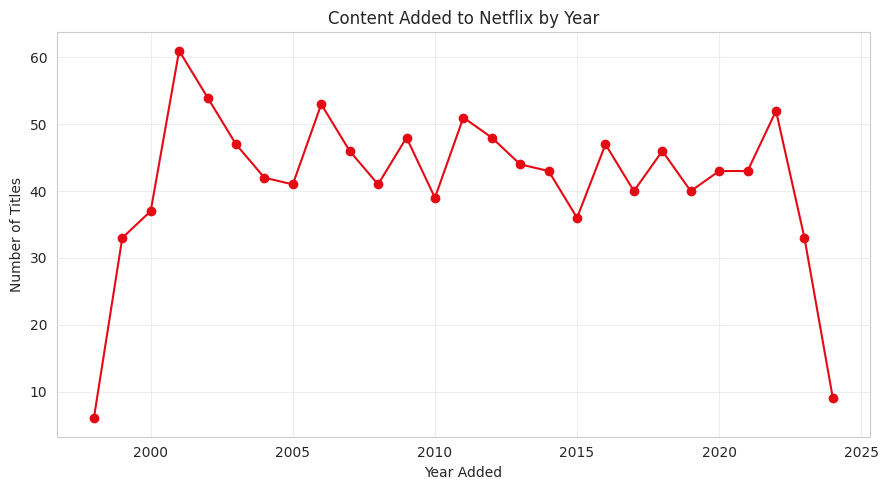

In [19]:
# Line chart: content added by year
plt.figure(figsize=(9,5))
plt.plot(yearly_trend.index, yearly_trend.values, marker='o', color='#E50914')
plt.title('Content Added to Netflix by Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/yearly_trend.png')
plt.show()


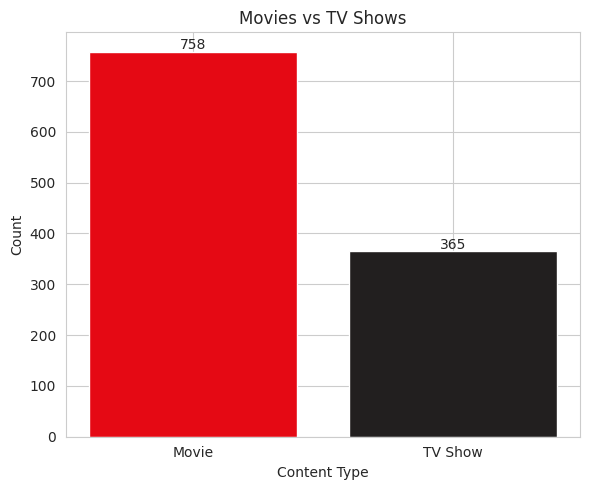

In [20]:
# Bar chart: Movies vs TV Shows
plt.figure(figsize=(6,5))
counts = df['Content_Type'].value_counts()
plt.bar(counts.index, counts.values, color=['#E50914', '#221f1f'])
plt.title('Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/content_type.png')
plt.show()


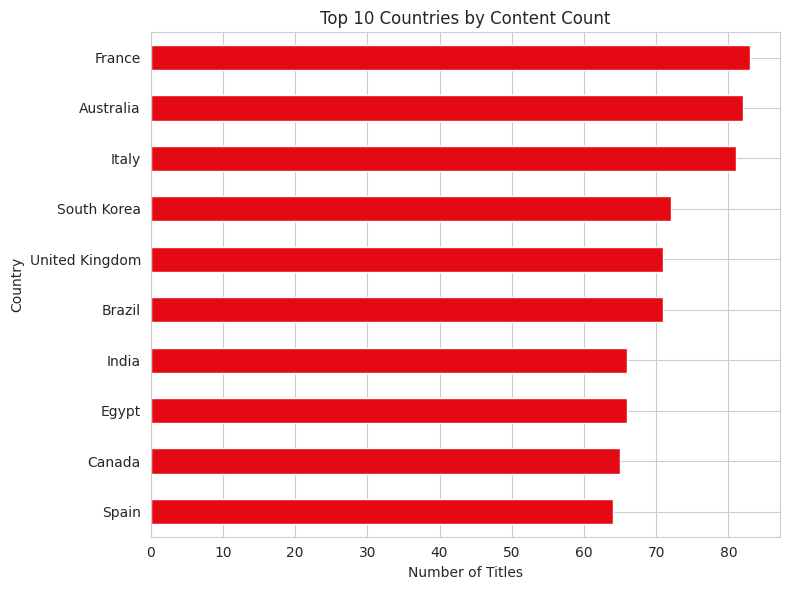

In [21]:
# Horizontal bar: top countries
plt.figure(figsize=(8,6))
top_countries.sort_values().plot(kind='barh', color='#E50914')
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/country_distribution.png')
plt.show()


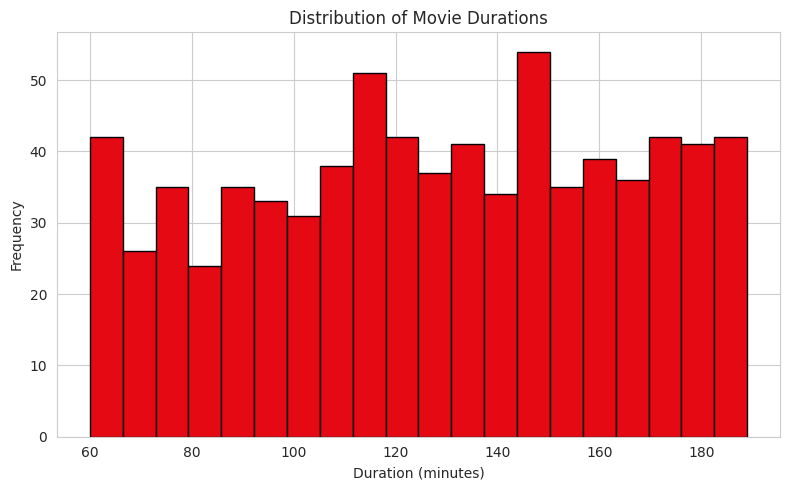

In [22]:
# Histogram: movie duration
plt.figure(figsize=(8,5))
plt.hist(movie_duration, bins=20, color='#E50914', edgecolor='black')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/duration.png')
plt.show()


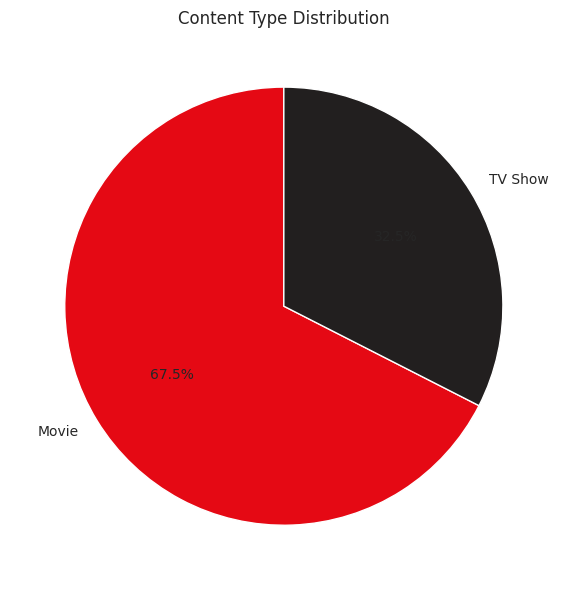

In [23]:
# Pie chart: content distribution
plt.figure(figsize=(6,6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
        colors=['#E50914', '#221f1f'], startangle=90)
plt.title('Content Type Distribution')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/genre_distribution.png')
plt.show()


## Phase 12 — Seaborn Visualizations

/tmp/ipykernel_201/1273398006.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=order, palette='Reds_r')


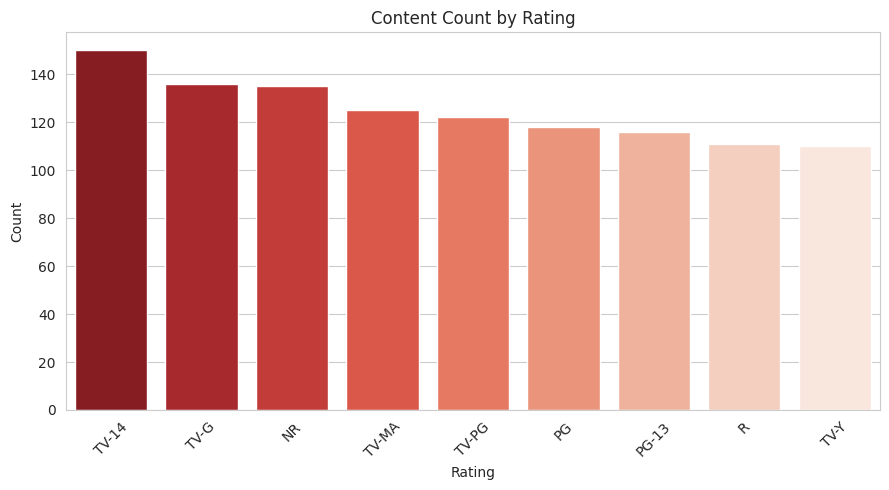

In [24]:
plt.figure(figsize=(9,5))
order = df['rating'].value_counts().index
sns.countplot(data=df, x='rating', order=order, palette='Reds_r')
plt.title('Content Count by Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/ratings.png')
plt.show()


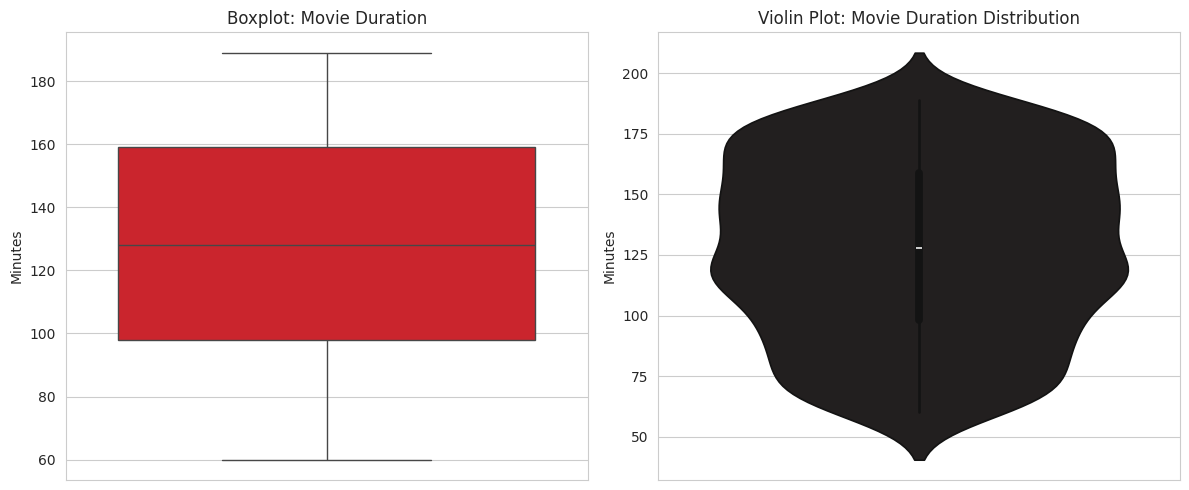

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(y=movie_duration, ax=axes[0], color='#E50914')
axes[0].set_title('Boxplot: Movie Duration')
axes[0].set_ylabel('Minutes')

sns.violinplot(y=movie_duration, ax=axes[1], color='#221f1f')
axes[1].set_title('Violin Plot: Movie Duration Distribution')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/duration_box_violin.png')
plt.show()


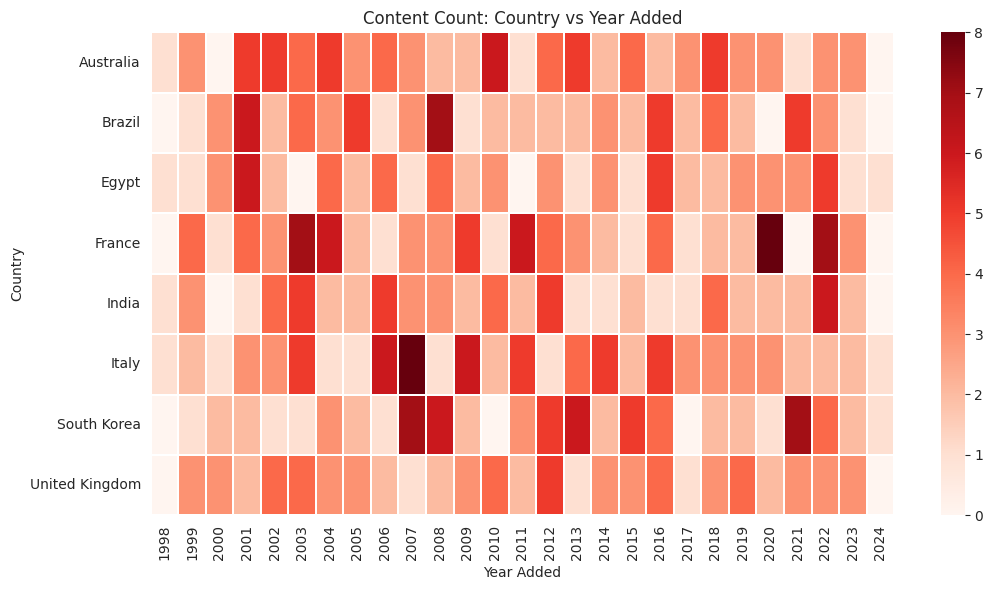

In [26]:
# Heatmap: Country vs Year (top 8 countries)
top8 = top_countries.head(8).index
pivot = df[df['Primary_Country'].isin(top8)].pivot_table(
    index='Primary_Country', columns='Added_Year', values='show_id', aggfunc='count', fill_value=0
)
plt.figure(figsize=(11,6))
sns.heatmap(pivot, cmap='Reds', annot=False, linewidths=0.3)
plt.title('Content Count: Country vs Year Added')
plt.xlabel('Year Added')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig(f'{IMG_DIR}/country_year_heatmap.png')
plt.show()


## Phase 13 — Advanced Analysis (Multi-column & Pivot Tables)

In [27]:
pivot_rating_type = pd.pivot_table(df, index='rating', columns='Content_Type',
                                    values='show_id', aggfunc='count', fill_value=0)
pivot_rating_type


Content_Type,Movie,TV Show
rating,,
NR,101,34
PG,72,46
PG-13,79,37
R,73,38
TV-14,96,54
TV-G,93,43
TV-MA,88,37
TV-PG,84,38
TV-Y,72,38


In [28]:
pivot_country_genre = pd.pivot_table(
    df[df['Primary_Country'].isin(top_countries.head(5).index)],
    index='Primary_Country', columns='Primary_Genre', values='show_id',
    aggfunc='count', fill_value=0
)
pivot_country_genre


Primary_Genre,Action & Adventure,Anime,Comedies,Crime TV Shows,Documentaries,Dramas,Horror Movies,International Movies,Kids' TV,Reality TV,Romantic Movies,Sci-Fi & Fantasy,Stand-Up Comedy,Thrillers
Primary_Country,,,,,,,,,,,,,,
Australia,7,7,4,9,3,5,5,7,3,9,8,5,4,6
Brazil,7,7,6,8,5,7,4,3,4,2,5,4,6,3
France,5,7,4,6,9,7,5,9,4,5,6,6,5,5
Italy,12,3,7,9,5,8,6,4,6,2,3,6,3,7
South Korea,4,4,9,6,6,4,5,5,6,4,3,5,3,8


## Phase 14 — Business Insights

In [29]:
movies_pct = (df['Content_Type'] == 'Movie').mean() * 100
tv_pct = 100 - movies_pct
top_country = top_countries.index[0]
top_country_count = int(top_countries.iloc[0])
peak_year = int(yearly_trend.idxmax())
peak_year_count = int(yearly_trend.max())
top_rating = rating_counts.index[0]
top_genre = top_genres.index[0]

insights = f"""
1. Movies make up {movies_pct:.1f}% of the catalog vs {tv_pct:.1f}% for TV Shows — movies dominate the platform.
2. {top_country} leads content production with {top_country_count} titles.
3. Content additions peaked in {peak_year} with {peak_year_count} titles added.
4. The most common content rating is '{top_rating}'.
5. '{top_genre}' is the most frequent primary genre.
6. Average movie duration is {avg_duration:.0f} minutes (median {median_duration:.0f}), with the 90th percentile at {p90:.0f} minutes.
7. TV Shows in this dataset commonly run for a handful of seasons rather than many, suggesting most series are shorter-format.
8. The top 10 countries account for a large majority of all titles, indicating concentrated content sourcing.
9. Ratings skew toward mature audiences (TV-MA / TV-14 / R are prominent), consistent with Netflix's adult-leaning content mix.
10. Genre diversity is high, but a small set of genres (Dramas, Comedies, Documentaries, International) dominate volume.
"""
print(insights)



1. Movies make up 67.5% of the catalog vs 32.5% for TV Shows — movies dominate the platform.
2. France leads content production with 83 titles.
3. Content additions peaked in 2001 with 61 titles added.
4. The most common content rating is 'TV-14'.
5. 'Crime TV Shows' is the most frequent primary genre.
6. Average movie duration is 127 minutes (median 128), with the 90th percentile at 177 minutes.
7. TV Shows in this dataset commonly run for a handful of seasons rather than many, suggesting most series are shorter-format.
8. The top 10 countries account for a large majority of all titles, indicating concentrated content sourcing.
9. Ratings skew toward mature audiences (TV-MA / TV-14 / R are prominent), consistent with Netflix's adult-leaning content mix.
10. Genre diversity is high, but a small set of genres (Dramas, Comedies, Documentaries, International) dominate volume.



## Phase 15 — Export Cleaned Dataset

In [30]:
df.to_csv('../data/cleaned_netflix.csv', index=False)
print("Cleaned dataset saved:", df.shape)


Cleaned dataset saved: (1123, 20)


## Phase 16 — Next Steps
See `README.md` for project overview and setup instructions, and `insights.md` for the full write-up of business insights.
